In [1]:
#imports
import DSKM
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Force PyVista to open in an EXTERNAL window instead of inline in the notebook
pv.set_jupyter_backend("client")

from DSKM.geometry import Material, Section, Part
from DSKM.meshing import Mesh
from DSKM.bound_cond import DOFManager
from DSKM.load import LoadManager
from DSKM.solver import GlobalAssembly, Solvers
from DSKM.postprocessing import Visualizer

# Geometrija in mreža

In [2]:
L = 0.3405  # Z-os
W = 0.2263  # X-os
H = 0.1000  # Y-os

x_steps = np.linspace(0, L, 4)

p = Part() #[cite: 2]
kn = {}

for i, x in enumerate(x_steps):
    # Spodnji nivo (Z = 0)
    kn[f"B_R_{i}"] = p.add_keynode([x, 0, 0]) # Spodaj desno
    kn[f"B_L_{i}"] = p.add_keynode([x, W, 0]) # Spodaj levo
    kn[f"B_M_{i}"] = p.add_keynode([x, W/2, 0]) # Spodaj sredina
    # Zgornji nivo (Z = H)
    kn[f"T_R_{i}"] = p.add_keynode([x, 0, H]) # Zgoraj desno
    kn[f"T_L_{i}"] = p.add_keynode([x, W, H]) # Zgoraj levo
    kn[f"T_M_{i}"] = p.add_keynode([x, W/2, H]) # Zgoraj srednia

square_tubes = []
for i in range(3):
    square_tubes.append(p.add_line(kn[f"B_R_{i}"], kn[f"B_R_{i+1}"]))
    square_tubes.append(p.add_line(kn[f"B_L_{i}"], kn[f"B_L_{i+1}"]))
    square_tubes.append(p.add_line(kn[f"T_R_{i}"], kn[f"T_R_{i+1}"]))
    square_tubes.append(p.add_line(kn[f"T_L_{i}"], kn[f"T_L_{i+1}"]))


I_profiles = []
# front_profiles
I_profiles.append(p.add_line(kn[f"T_L_0"], kn[f"T_M_0"]))
I_profiles.append(p.add_line(kn[f"T_M_0"], kn[f"T_R_0"]))
I_profiles.append(p.add_line(kn[f"B_L_0"], kn[f"B_M_0"]))
I_profiles.append(p.add_line(kn[f"B_M_0"], kn[f"B_R_0"]))

# rear profiles
I_profiles.append(p.add_line(kn[f"T_L_3"], kn[f"T_M_3"]))
I_profiles.append(p.add_line(kn[f"T_M_3"], kn[f"T_R_3"]))
I_profiles.append(p.add_line(kn[f"B_L_3"], kn[f"B_M_3"]))
I_profiles.append(p.add_line(kn[f"B_M_3"], kn[f"B_R_3"]))


T_profiles_top = []
T_profiles_bottom = []
for i in range(1,3):
    T_profiles_top.append(p.add_line(kn[f"T_L_{i}"], kn[f"T_M_{i}"]))
    T_profiles_top.append(p.add_line(kn[f"T_M_{i}"], kn[f"T_R_{i}"]))
    # T_profiles_top.append(p.add_line(kn[f"T_M_{i}"], kn[f"T_R_{i}"]))
    # T_profiles_top.append(p.add_line(kn[f"T_L_{i}"], kn[f"T_M_{i}"]))
    # T_profiles_top.append(p.add_line(kn[f"T_M_{i}"], kn[f"T_M_{i+1}"]))

    T_profiles_bottom.append(p.add_line(kn[f"B_L_{i}"], kn[f"B_M_{i}"]))
    T_profiles_bottom.append(p.add_line(kn[f"B_M_{i}"], kn[f"B_R_{i}"]))
    # T_profiles_bottom.append(p.add_line(kn[f"B_L_{i}"], kn[f"B_M_{i}"]))
    # T_profiles_bottom.append(p.add_line(kn[f"B_M_{i}"], kn[f"B_R_{i}"]))
    # T_profiles_bottom.append(p.add_line(kn[f"B_M_{i}"], kn[f"B_M_{i+1}"]))

for i in range(3):
    T_profiles_top.append(p.add_line(kn[f"T_M_{i}"], kn[f"T_M_{i+1}"]))
    T_profiles_bottom.append(p.add_line(kn[f"B_M_{i}"], kn[f"B_M_{i+1}"]))


L_connecting = []
# front connecting
L_connecting.append(p.add_line(kn["B_L_0"], kn["T_L_0"]))
L_connecting.append(p.add_line(kn["B_R_0"], kn["T_R_0"]))

# rear connecting
L_connecting.append(p.add_line(kn["B_L_3"], kn["T_L_3"]))
L_connecting.append(p.add_line(kn["B_R_3"], kn["T_R_3"]))


Truss_connections = []
Truss_connections.append(p.add_line(kn["B_R_0"], kn["T_L_0"]))
Truss_connections.append(p.add_line(kn["B_L_0"], kn["T_R_0"]))
Truss_connections.append(p.add_line(kn["B_R_3"], kn["T_L_3"]))
Truss_connections.append(p.add_line(kn["B_L_3"], kn["T_R_3"]))

Visualizer.plot_part(p)


# print(x_steps)

Widget(value='<iframe src="http://localhost:63552/index.html?ui=P_0x1fe08b65ca0_0&reconnect=auto" class="pyvis…

In [3]:
# material properties
alu = Material(name="alu", E=6.8950e10, G=2.6e10, rho=2700, alpha=1e-4, beta=1e-5) 
# sections
I_profil = Section(name="I_profil", A =62e-6, Iy=340.67e-12, Iz=1925.17e-12, It=88.33e-12, Ip=340.67e-12+1925.17e-12)
T_profil = Section(name="T_profil", A=36e-6, Iy = 172e-12, Iz=314.22e-12, It=49.18e-12, Ip=172e-12+314.22e-12)
SQ_frame = Section(name="SQ_frame", A=144e-6, Iy=1728e-12, Iz=1728e-12, It=2932.15e-12, Ip=2*1728e-12)
SQ_truss = Section(name="SQ_truss", A=25e-6, Iy=52.08e-12, Iz=52.08e-12, It=88.68e-12, Ip=2*52.08e-12)

In [4]:
# assign sections to elements

# SQ_frame
p.assign_property(square_tubes, material=alu, section=SQ_frame, elem_type="Frame3D", v_up=[0,0,1])
# SQ_truss
p.assign_property(Truss_connections, material=alu, section=SQ_truss, elem_type="Truss3D", v_up=[0,0,1])
# T profili bottom
p.assign_property(T_profiles_bottom, material=alu, section=T_profil, elem_type="Frame3D", v_up=[0,0,1])
# T profili top
p.assign_property(T_profiles_top, material=alu,section=T_profil, elem_type="Frame3D", v_up=[0,0,-1])

# I profili (spredaj zgoraj) # lokalna y os gleda v x smeri
p.assign_property(I_profiles[:2], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0]) 

# I profili (spredaj spodaj) # lokalna y os gleda v x smeri
p.assign_property(I_profiles[2:4], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0])

# I profili (zadaj zgoraj) # lokalna y os gleda v -x smeri
p.assign_property(I_profiles[4:6], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0]) 

# I profili (zadaj spodaj) # lokalna y os gleda v -x smeri
p.assign_property(I_profiles[6:8], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0]) 

# I profili (spredaj vertikalni levi) # lokalna y os gleda v x smeri
p.assign_property([L_connecting[0]], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0]) 

# I profili (spredaj vertikalni desni)# lokalna y os gleda v x smeri
p.assign_property([L_connecting[1]], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0]) 

# I profili (zadaj vertikalni levi)# lokalna y os gleda v -x smeri
p.assign_property([L_connecting[2]], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0]) 

# I profili (zadaj vertikalni desni)# lokalna y os gleda v -x smeri
p.assign_property([L_connecting[3]], material=alu, section=I_profil, elem_type="Frame3D", v_up=[1, 0, 0])

In [5]:
mesh = Mesh()
mesh.generate_mesh(part=p, global_size=0.005)

# DOF and Load manager
dm = DOFManager(mesh)
lm = LoadManager(mesh, dm)

# visualize mesh
vis = Visualizer(mesh, dm, lm)

vis.plot_mesh()
print(f"Število vozlišč: {len(mesh.nodes)}")
print(f"Število PS: {6*len(mesh.nodes)}")
print(f"Število elementov: {len(mesh.elements)}")


Widget(value='<iframe src="http://localhost:63552/index.html?ui=P_0x1fe09bf2a20_1&reconnect=auto" class="pyvis…

Število vozlišč: 848
Število PS: 5088
Število elementov: 866


In [6]:
# robni pogoji - enako kot ansys

dm.fix_all(node_id=kn["B_R_1"]) # zaklemeno premike
dm.fix_all(node_id=kn["B_R_2"]) # zaklemeno premike
dm.fix_all(node_id=kn["B_L_1"]) # zaklemeno premike
dm.fix_all(node_id=kn["B_L_2"]) # zaklemeno premike
dm.fix_all(node_id=kn["B_M_1"]) # zaklemeno premike
dm.fix_all(node_id=kn["B_M_2"]) # zaklemeno premike
dm.auto_constrain_trusses()

vis.plot_mesh()

Widget(value='<iframe src="http://localhost:63552/index.html?ui=P_0x1fe09bf3680_2&reconnect=auto" class="pyvis…

# Modalna Analiza

In [7]:
# naredimo modalno analizo
assembly = GlobalAssembly(mesh=mesh, dof_manager=dm)
K, M, C = assembly.assemble_matrices()
solver = Solvers(K, M, C, dm)

eig_vals, eig_vecs = solver.solve_eigen()
vis.print_frequency_table(eig_vals[:30])


Mode       | Frekvenca [Hz] 
------------------------------
1          | 167.839        
2          | 217.329        
3          | 236.829        
4          | 250.635        
5          | 343.123        
6          | 386.959        
7          | 415.198        
8          | 481.466        
9          | 546.312        
10         | 585.034        
11         | 606.746        
12         | 614.416        
13         | 645.700        
14         | 704.007        
15         | 796.833        
16         | 866.041        
17         | 884.506        
18         | 1058.378       
19         | 1149.415       
20         | 1335.938       
21         | 1446.919       
22         | 1655.361       
23         | 1741.173       
24         | 1834.061       
25         | 1839.888       
26         | 1953.216       
27         | 2024.075       
28         | 2222.025       
29         | 2262.631       
30         | 2281.752       



In [8]:
vis.animate_mode_shape(eig_vals, eig_vecs, mode_idx=0, scale=1)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Mode: 1 | Freq: 167.84 Hz | Speed: 1.00x   

In [10]:
# primerjava lastnih frekvenc med lastno izvedbo in ansys (odstopanje v %)
df_ansys = pd.read_csv("ANSYS_data/mode_freqs.txt", sep="\t", decimal=",", index_col=0)
df_ansys = df_ansys.dropna(axis=1, how="all")

freqs_ansys = df_ansys["Frequency [Hz]"]
freqs_py = eig_vals[:30]**0.5/2/np.pi # da pridemo do Hz

np.mean(np.abs((freqs_ansys - freqs_py)/freqs_ansys) * 100)

np.float64(3.929209234256904)

C:\Users\enejp\AppData\Local\Temp\ipykernel_27332\3791427435.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_ansys = pd.read_csv("ANSYS_data/mode_freqs.txt", sep="\\t", decimal=",", index_col=0)


,Freq Python [Hz],Freq Ansys [Hz],Napaka [%]
Mode,,,
1,167.84,166.20,0.99
2,217.33,204.03,6.52
3,236.83,231.27,2.40
4,250.64,316.64,20.85
5,343.12,326.46,5.10
6,386.96,357.26,8.31
7,415.20,402.52,3.15
8,481.47,483.17,0.35
9,546.31,529.20,3.23


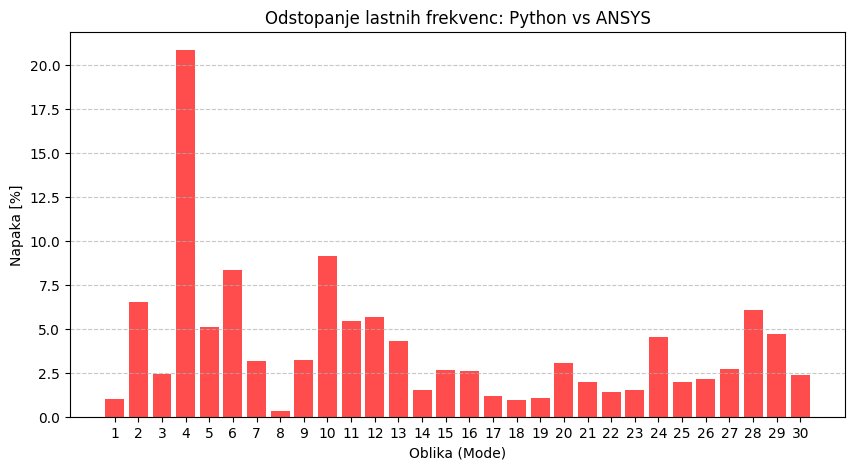

In [11]:
# primerjava lastnih frekvenc med lastno izvedbo in ansys (odstopanje v %)",
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
df_ansys = pd.read_csv("ANSYS_data/mode_freqs.txt", sep="\\t", decimal=",", index_col=0)
df_ansys = df_ansys.dropna(axis=1, how="all")

freqs_ansys = df_ansys["Frequency [Hz]"].values[:30]
freqs_py = (eig_vals[:30]**0.5) / (2 * np.pi) # da pridemo do Hz"
# Izračun napake",
error_pct = np.abs(freqs_py - freqs_ansys) / freqs_ansys * 100

# Prikaz v tabeli",
df_comp = pd.DataFrame({
    "Freq Python [Hz]": freqs_py,
    "Freq Ansys [Hz]": freqs_ansys,
    "Napaka [%]": error_pct
}, index=range(1, len(freqs_py)+1))
df_comp.index.name = "Mode"

display(df_comp.round(2))

# Grafični prikaz napake",
plt.figure(figsize=(10, 5))
plt.bar(df_comp.index, df_comp["Napaka [%]"], color="red", alpha=0.7)
plt.xlabel("Oblika (Mode)")
plt.ylabel("Napaka [%]")
plt.title("Odstopanje lastnih frekvenc: Python vs ANSYS")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(df_comp.index)
plt.show()

# Harmonska Analiza

In [12]:
# dodajanje sile na node
lm.clear_loads()
lm.add_nodal_load(node_id=kn["T_L_0"], fz=1000*np.exp(1j*0))
lm.add_nodal_load(node_id=kn["T_R_0"], fz=1000*np.exp(1j*np.pi/2))
vis.plot_mesh()

Widget(value='<iframe src="http://localhost:63552/index.html?ui=P_0x1fe09cba0f0_3&reconnect=auto" class="pyvis…

In [13]:
# freq_sweep
f_hz = np.linspace(0,300, 1000)
f_rad = f_hz*2*np.pi

# harmonic response
U_harm = solver.solve_harmonic(lm.get_global_force(), f_rad)

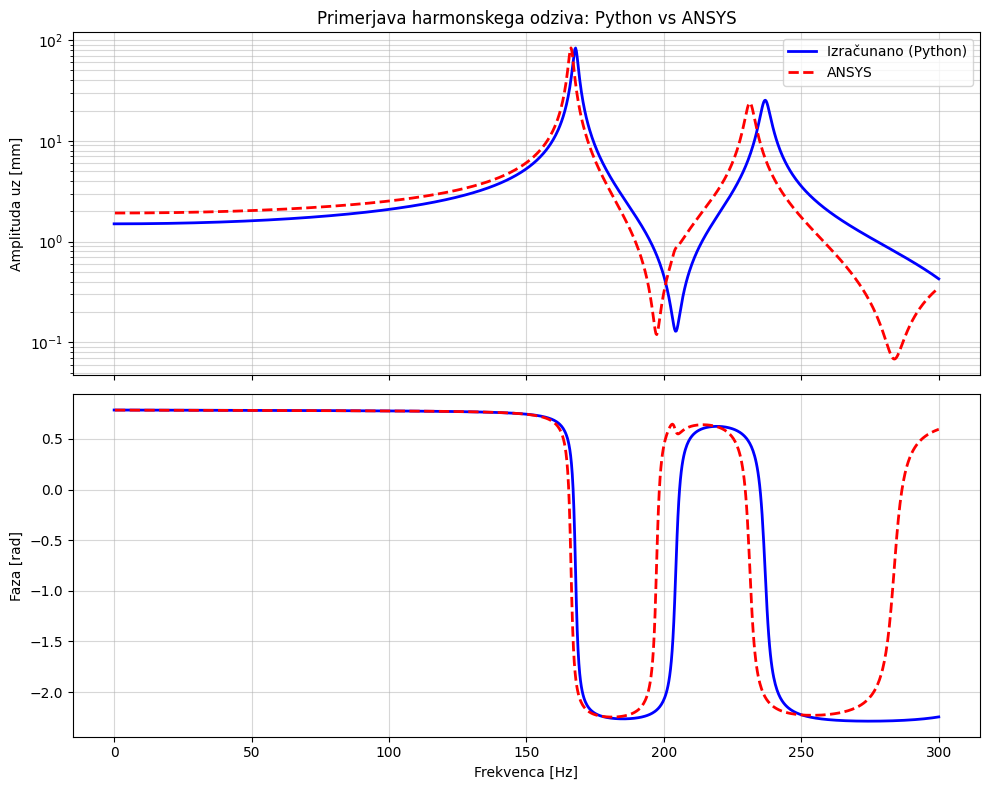

In [14]:
# primerjava z resitvijo iz ansysa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Naložimo rezultate iz ANSYS-a
df_ansys = pd.read_csv("ANSYS_data/harmonska.txt", sep="\t", decimal=",", index_col=0)
df_ansys = df_ansys.dropna(axis=1, how="all")

freqs_ansys = df_ansys["Frequency [Hz]"]
amp_ansys = df_ansys["Amplitude [mm]"]
phase_ansys = np.unwrap(df_ansys["Phase Angle [°]"]*np.pi/180)

# 2. Pridobimo naše izračunane rezultate za vozlišče t2, prostostna stopnja "ux"
# Vemo, da je "ux" na indeksu 0 (glede na mapiranje: ux=0, uy=1, uz=2, rx=3, ry=4, rz=5)
idx = 6 * kn["B_M_0"] + 2
response_calc = U_harm[idx, :]

# Frekvence [Hz], amplitude (pretvori v mm) in faze (pretvori v stopinje)
freqs_calc = f_rad / (2 * np.pi)
amp_calc_mm = np.abs(response_calc) * 1000
phase_calc_deg = np.unwrap(np.angle(response_calc, deg=False))

# 3. Izrišemo primerjavo na dveh podgrafih (amplituda in faza)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Amplitudni graf (y-os je logaritemska) ---
ax1.semilogy(freqs_calc, amp_calc_mm, label="Izračunano (Python)", color="blue", lw=2)
ax1.semilogy(freqs_ansys, amp_ansys, label="ANSYS", color="red", linestyle="--", lw=2)
ax1.set_ylabel("Amplituda uz [mm]")
ax1.grid(True, which="both", ls="-", alpha=0.5)
ax1.set_title("Primerjava harmonskega odziva: Python vs ANSYS")
ax1.legend()

# --- Fazni graf ---
ax2.plot(freqs_calc, phase_calc_deg, label="Izračunano (Python)", color="blue", lw=2)
ax2.plot(freqs_ansys, phase_ansys, label="ANSYS", color="red", linestyle="--", lw=2)
ax2.set_ylabel("Faza [rad]")
ax2.set_xlabel("Frekvenca [Hz]")
ax2.grid(True, alpha=0.5)
# ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
vis.animate_harmonic(omega_sweep=f_rad, U_full=U_harm, start_idx=0, scale=2, highlight_node=kn["B_M_0"])

>>> [ANSYS SWEEP] Vzbujevalna Frekvenca: 8.41 Hz | Hitrost: 1.00x | Auto-Sweep: ON  <<<   

# Časovna integracija

In [16]:
t_eval = np.linspace(0, 1.0, 1000)
dt = t_eval[1] - t_eval[0]
n_steps = len(t_eval)
F_int = np.zeros((dm.n_dof, n_steps))

node_1 = kn["T_L_0"]
idx_1 = 6 * node_1 + 1  # Y smer
# Parametri 1. udarca
t_start_1 = 0.05
dur_1 = 0.05  # Traja 50 ms
mag_1 = 1000.0 # 1000 N

# Generiranje polovičnega sinusa
mask_1 = (t_eval >= t_start_1) & (t_eval <= t_start_1 + dur_1)
F_int[idx_1, mask_1] = mag_1 * np.sin(np.pi * (t_eval[mask_1] - t_start_1) / dur_1)

node_2 = kn["T_R_0"]
idx_2 = 6 * node_2 + 1  # Y smer
# Parametri 2. udarca 
t_start_2 = 0.15
dur_2 = 0.05
mag_2 = 1500.0 # 1500 N

# Generiranje polovičnega sinusa
mask_2 = (t_eval >= t_start_2) & (t_eval <= t_start_2 + dur_2)
F_int[idx_2, mask_2] = mag_2 * np.sin(np.pi * (t_eval[mask_2] - t_start_2) / dur_2)

In [19]:
import time
# reševanje
x0 = np.zeros(dm.n_dof)
v0 = np.zeros(dm.n_dof)

t0 = time.time()
U_int, _, _ = solver.solve_integration_newmark(F_int, dt, x0, v0, gamma=0.5, beta=0.25)
print(f"Končano v {time.time()-t0:.4f} sekundah")

100%|██████████| 999/999 [00:16<00:00, 62.21it/s]


Končano v 20.9530 sekundah


In [ ]:
# sila ansys
F_y1 = F_int[idx_1, :]
F_y2 = F_int[idx_2, :]
F_xz = np.zeros_like(t_eval)
#  Node 1
df_node1 = pl.DataFrame({
    "Time [s]": t_eval,
    "Fx [N]": F_xz,
    "Fy [N]": F_y1,
    "Fz [N]": F_xz
})

#  Node 2
df_node2 = pl.DataFrame({
    "Time [s]": t_eval,
    "Fx [N]": F_xz,
    "Fy [N]": F_y2,
    "Fz [N]": F_xz
})

df_node1.write_excel("force_TL0")
df_node2.write_excel("force_TR0")


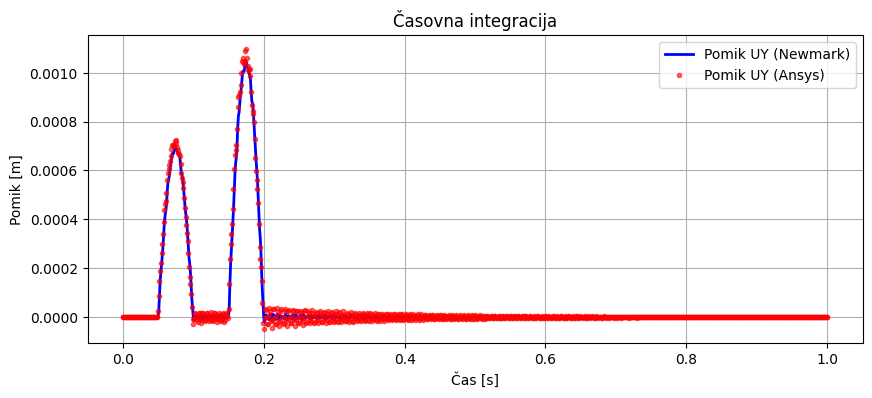

In [18]:
# 1. Naložimo rezultate iz ANSYS-a
node_3 = kn["B_M_0"]
idx_3 = 6 * node_3 + 1  # Z is the 3rd DOF (index 2)
df_ansys = pd.read_csv("ANSYS_data/cas_int.txt", sep="\t", decimal=",", index_col=0)
df_ansys = df_ansys.dropna(axis=1, how="all")
defo = df_ansys["Average [mm]"]

plt.figure(figsize=(10, 4))
plt.plot(t_eval, U_int[idx_3, :], label="Pomik UY (Newmark)", color="blue", lw=2)
plt.plot(t_eval, defo/1000, ".", label="Pomik UY (Ansys)", color="red", alpha=0.6)
plt.title("Časovna integracija")
plt.xlabel("Čas [s]")
plt.ylabel("Pomik [m]")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
vis.animate_transient(t_eval, U_int, highlight_node=node_3)